### Cieľ spracovania
V tejto časti sme si definovali hlavné kroky spracovania dát pre malú oblasť. 
Našim cieľom je načítať vstupné dáta (DEM a masku), vytvoriť kandidátov budov, pripraviť vstupy pre klasifikačný algoritmus a následne vykonať samotnú klasifikáciu objektov.

### Import knižníc
Na začiatku importujeme všetky potrebné knižnice pre spracovanie dát. 
Používame knižnice na prácu s obrazom - `cv2`, numerické výpočty - `NumPy`, s tabuľkovými výstupmi - `Pandas`, vizualizáciu - `Matplotlib` a načítanie rasterových dát - `Rasterio`. 

Z knižnice `collections` importujeme triedu `Counter`, ktorú využívame na zistenie rozdelenia objektov do jednotlivých tried. Zároveň importujeme vlastnú triedu `Detector`, ktorá zabezpečuje výpočet príznakov a samotnú klasifikáciu objektov.

Na uloženie vizualizácií a súboru pre QGIS vytvoríme priečinky `vizualizacie` a `QGIS_CSV`.

In [1]:
import os
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import rasterio

from detector_my import Detector

plt.rcParams['figure.figsize'] = (10, 10)
os.makedirs('vizualizacie', exist_ok=True)
os.makedirs('QGIS_CSV', exist_ok=True)


### Načítanie vstupných dát
V tomto kroku načítavame digitálny výškový model (DEM) a segmentačnú masku zo súborov. 

Vytvoríme inštanciu triedy `Detector`, ktorá zabezpečuje výpočet doplnkových príznakov potrebných pre klasifikáciu objektov.

Dáta načítavame pomocou knižnice Rasterio a následne ich prevádzame do vhodného numerického formátu pre ďalšie spracovanie.
Taktiež si vypíšeme tvary DEM a segmentačnej masky a jej unikátne hodnoty.

In [2]:
DEM_PATH = 'zdroj/ClippedDEM.tif'
MASK_PATH = 'zdroj/ClippedMask.tif'

detector_my = Detector()

with rasterio.open(DEM_PATH) as src:
    dem = src.read(1).astype(np.float32)

with rasterio.open(MASK_PATH) as src:
    mask = src.read(1)

mask_bin = (mask > 0).astype(np.uint8)

print('DEM shape:', dem.shape)
print('Mask shape:', mask_bin.shape)
print('Mask unique values:', np.unique(mask_bin))


DEM shape: (383, 614)
Mask shape: (383, 614)
Mask unique values: [0 1]


### Vizualizácia vstupných dát
Pre lepšie pochopenie dát si vytvárame vizualizáciu DEM a masky. 
Normalizujeme hodnoty DEM do rozsahu 0–255 a zobrazujeme ich ako obraz, aby sme mohli vizuálne skontrolovať kvalitu vstupov. Následne si vykreslíme obe vstupné dáta vedľa seba pomocou knižnice matplotlib.

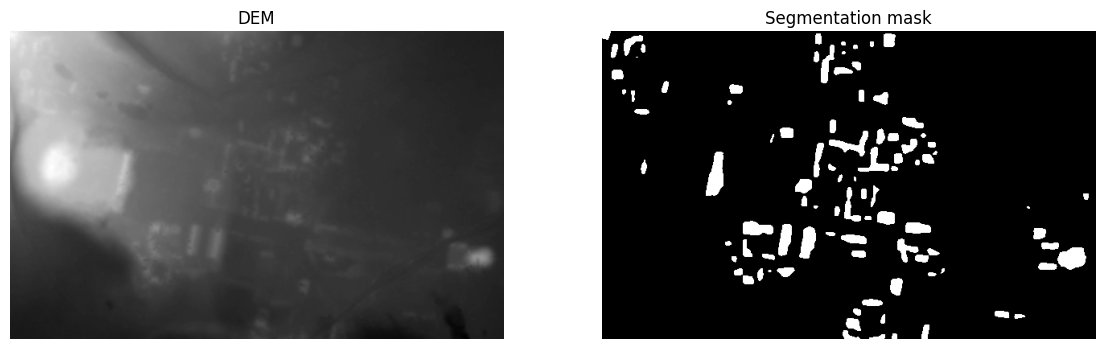

In [3]:
lidar_map = cv2.normalize(dem, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
lidar_map = cv2.cvtColor(lidar_map, cv2.COLOR_GRAY2BGR)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(dem, cmap='gray')
ax[0].set_title('DEM')
ax[0].axis('off')

ax[1].imshow(mask_bin, cmap='gray')
ax[1].set_title('Segmentation mask')
ax[1].axis('off')
plt.show()


### Čistenie segmentačnej masky
V tomto kroku vykonávame jemné čistenie masky pomocou morfologických operácií. 
Cieľom je odstrániť šum a malé nežiaduce objekty, pričom sa snažíme zachovať čo najviac relevantných kandidátov budov.

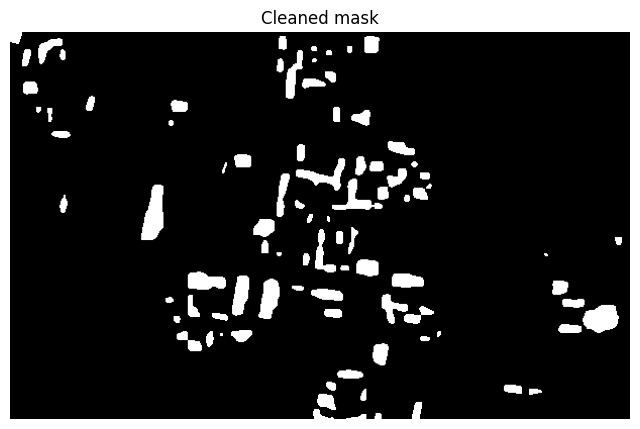

In [4]:
def clean_mask_for_recall(mask_bin):
    mask_u8 = (mask_bin * 255).astype(np.uint8)
    opened = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    return (closed > 0).astype(np.uint8)

cleaned_mask = clean_mask_for_recall(mask_bin)

plt.figure(figsize=(8, 8))
plt.imshow(cleaned_mask, cmap='gray')
plt.title('Cleaned mask')
plt.axis('off')
plt.show()


### Pomocné funkcie
V tejto bunke definujeme pomocné funkcie, ktoré využívame pri spracovaní kontúr a výpočte príznakov objektov. Funkcie sú priamo naviazané na prácu s maskou objektu a hodnotami z digitálneho výškového modelu (DEM).

Funkcia `contour_mask` vytvára binárnu masku objektu na základe jeho kontúry. Inicializujeme nulové pole s rovnakým rozmerom ako vstupný obraz a pomocou funkcie `cv2.drawContours` vyplníme oblasť kontúry hodnotou 1, čím získame masku objektu.

Funkcia `compute_height_difference` počíta výškový rozdiel medzi objektom a jeho okolím. Najprv masku objektu rozšírime pomocou morfologickej operácie dilatácie a z rozdielu medzi rozšírenou maskou a pôvodnou maskou vytvoríme prstenec okolo objektu. Následne vypočítame priemernú výšku vnútri objektu a v tomto prstenci a ako výsledok vraciame ich rozdiel spolu s jednotlivými priemermi.

Funkcia `contour_features` zabezpečuje výpočet všetkých hlavných príznakov objektu. Z kontúry získavame plochu, obvod a ohraničujúci obdĺžnik, z ktorého určujeme rozmery a pomer strán. Ďalej počítame konvexný obal na určenie solidity, pomer zaplnenia bounding boxu (extent) a aproximujeme kontúru na získanie počtu vrcholov. Následne vytvoríme masku objektu a pomocou predchádzajúcej funkcie doplníme aj výškové príznaky.

Funkcia `keep_as_candidate` vykonáva základné filtrovanie objektov na základe vypočítaných príznakov. Postupne kontrolujeme minimálne rozmery, plochu, pomer strán, kombináciu extent a solidity a tiež výškový rozdiel. Objekty, ktoré nespĺňajú tieto podmienky, vyradíme a do ďalšieho spracovania ponecháme len vhodných kandidátov.

In [5]:
def contour_mask(shape, contour):
    tmp = np.zeros(shape, dtype=np.uint8)
    cv2.drawContours(tmp, [contour], -1, 1, thickness=-1)
    return tmp


def compute_height_difference(dem, obj_mask, ring_size=3):
    obj_mask_u8 = obj_mask.astype(np.uint8)
    kernel = np.ones((ring_size, ring_size), np.uint8)
    dilated = cv2.dilate(obj_mask_u8, kernel, iterations=2)
    ring = ((dilated == 1) & (obj_mask_u8 == 0)).astype(np.uint8)

    obj_vals = dem[obj_mask_u8 == 1]
    ring_vals = dem[ring == 1]

    obj_vals = obj_vals[np.isfinite(obj_vals)]
    ring_vals = ring_vals[np.isfinite(ring_vals)]

    if len(obj_vals) == 0:
        return 0.0, np.nan, np.nan

    obj_mean = float(np.mean(obj_vals))
    if len(ring_vals) == 0:
        return 0.0, obj_mean, np.nan

    ring_mean = float(np.mean(ring_vals))
    return float(obj_mean - ring_mean), obj_mean, ring_mean


def contour_features(contour, dem):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    x, y, w, h = cv2.boundingRect(contour)
    bbox_area = max(w * h, 1)

    rect = cv2.minAreaRect(contour)
    short_side = min(w, h)
    long_side = max(w, h)
    aspect_ratio = long_side / short_side if short_side > 0 else 999.0

    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0.0
    extent = area / bbox_area if bbox_area > 0 else 0.0

    epsilon = 0.02 * perimeter if perimeter > 0 else 1.0
    approx = cv2.approxPolyDP(contour, epsilon, True)

    obj_mask = contour_mask(dem.shape, contour)
    height_diff, mean_obj_height, mean_ring_height = compute_height_difference(dem, obj_mask)

    return {
        'contour': contour,
        'rect': rect,
        'bbox': (x, y, w, h),
        'area': float(area),
        'perimeter': float(perimeter),
        'short_side': float(short_side),
        'long_side': float(long_side),
        'aspect_ratio': float(aspect_ratio),
        'solidity': float(solidity),
        'extent': float(extent),
        'approx_vertices': int(len(approx)),
        'height_diff': float(height_diff),
        'mean_obj_height': float(mean_obj_height) if np.isfinite(mean_obj_height) else np.nan,
        'mean_ring_height': float(mean_ring_height) if np.isfinite(mean_ring_height) else np.nan,
        'obj_mask': obj_mask,
    }


def keep_as_candidate(feat):
    w = feat['bbox'][2]
    h = feat['bbox'][3]
    area = feat['area']
    aspect_ratio = feat['aspect_ratio']
    extent = feat['extent']
    solidity = feat['solidity']
    height_diff = feat['height_diff']

    if w < 3 or h < 3:
        return False
    if area < 8:
        return False
    if aspect_ratio > 12:
        return False
    if extent < 0.08 and solidity < 0.2:
        return False
    if height_diff < -0.5:
        return False
    return True


### Extrakcia kontúr a výber kandidátov
V tomto kroku extrahujeme kontúry zo segmentačnej masky pomocou funkcie `cv2.findContours`. Masku najprv prevedieme na 8-bitový formát a škálujeme na hodnoty 0–255, aby bola kompatibilná s OpenCV.

Pre každú získanú kontúru následne vypočítame príznaky pomocou funkcie `contour_features`. Tieto príznaky zahŕňajú geometrické aj výškové charakteristiky objektu.

Pomocou funkcie `keep_as_candidate` vykonávame základné filtrovanie kontúr. Do zoznamu kandidátov pridávame iba tie objekty, ktoré spĺňajú definované podmienky.

Na konci vypisujeme celkový počet nájdených kontúr a počet objektov, ktoré boli vybrané ako kandidáti na ďalšie spracovanie.

In [6]:
contours, hierarchy = cv2.findContours((cleaned_mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

candidate_features = []
for cnt in contours:
    feat = contour_features(cnt, dem)
    if keep_as_candidate(feat):
        candidate_features.append(feat)

print('Počet všetkých contours:', len(contours))
print('Počet candidate_features:', len(candidate_features))


Počet všetkých contours: 89
Počet candidate_features: 87


### Vizualizácia kandidátov
V tomto kroku vizualizujeme všetky objekty, ktoré boli vybrané ako kandidáti na ďalšie spracovanie. Vytvárame kópiu vstupného obrazu, do ktorej postupne zakresľujeme jednotlivé objekty.

Pre každý kandidátsky objekt vykreslíme ohraničujúci obdĺžnik na základe jeho bounding boxu. Zároveň ku každému objektu pridávame index, ktorý nám umožňuje jednoduchú identifikáciu pri ďalšej analýze.

Výsledný obraz zobrazujeme pomocou knižnice matplotlib, pričom zabezpečíme farebné zobrazenie. Vizualizáciu zároveň ukladáme do súboru  vizualizacie pre neskoršie použitie a dokumentáciu výsledkov pred klasifikáciou.

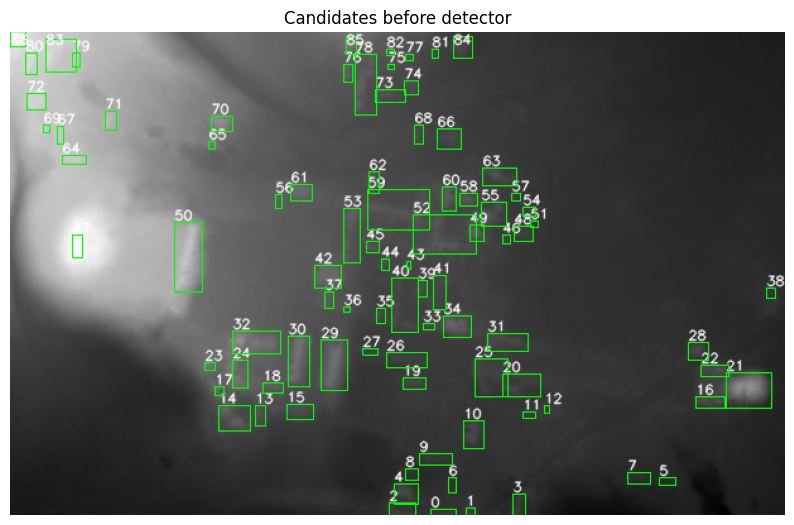

True

In [7]:
preview_candidates = lidar_map.copy()
for i, feat in enumerate(candidate_features):
    x, y, w, h = feat['bbox']
    cv2.rectangle(preview_candidates, (x, y), (x + w, y + h), (0, 255, 0), 1)
    cv2.putText(preview_candidates, str(i), (x, max(10, y - 2)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(10, 10))
plt.imshow(preview_candidates[..., ::-1])
plt.title('Candidates before detector')
plt.axis('off')
plt.show()

cv2.imwrite('vizualizacie/candidates_before_classification.jpg', preview_candidates)


### Príprava vstupov pre klasifikáciu
V tomto kroku pripravujeme vstupné dáta pre klasifikačný algoritmus. Inicializujeme jednotlivé zoznamy, do ktorých budeme ukladať masky objektov, výškové dáta, rozmery a súradnice.

Pre každý kandidátsky objekt získavame jeho ohraničujúci obdĺžnik a rotovaný obdĺžnik. Na základe súradníc následne vyrezávame príslušnú časť masky objektu a digitálneho výškového modelu.

Vyrezanú masku a výškové dáta ukladáme do zoznamov `house` a `house_height`. Zároveň si uchovávame rozmery objektu (`house_size`), jeho polohu (`house_cord`) a rotovaný obdĺžnik (`rectangles_for_angles`), ktorý bude neskôr využitý pri výpočte orientácie.

Na záver vypisujeme počty pripravených objektov, aby sme overili správnosť spracovania vstupných dát.

In [8]:
house = []
house_height = []
house_size = []
house_cord = []
rectangles_for_angles = []

for feat in candidate_features:
    x, y, w, h = feat['bbox']
    rect = feat['rect']

    obj_mask_full = feat['obj_mask']
    obj_mask_crop = obj_mask_full[y:y+h, x:x+w]
    dem_crop = dem[y:y+h, x:x+w]

    house.append(obj_mask_crop.astype(np.uint8))
    house_height.append(dem_crop.astype(np.float32))
    house_size.append([w, h])
    house_cord.append([x, y, w, h])
    rectangles_for_angles.append(rect)

print('Počet house segmentov:', len(house))
print('Počet house_size:', len(house_size))
print('Počet house_cord:', len(house_cord))


Počet house segmentov: 87
Počet house_size: 87
Počet house_cord: 87


### Výpočet doplnkových príznakov
Pomocou metódy `compute_difference` vypočítavame pre každý objekt hodnotu rozdielu na základe jeho masky a príslušných výškových dát, ktoré sme uložili do premennej difference.

Pomocou metódy `determine_building_orientations` určujeme orientáciu jednotlivých objektov na základe rotovaných obdĺžnikov. Takto získaná orientácia sa využívala pre určenie budov typu juego.

In [9]:
difference = detector_my.compute_difference(house, house_height)
orientation = detector_my.determine_building_orientations(rectangles_for_angles)

### Klasifikácia objektov
V tomto kroku vykonávame samotnú klasifikáciu objektov pomocou triedy `Detector`. Najprv si vytvárame kópiu vstupného obrazu, do ktorej budú zakreslené výsledky.

Volaním metódy `find_buildings` odovzdávame všetky pripravené vstupy, ako sú masky objektov, ich orientácia, rozmery, súradnice, výškové rozdiely a výškové dáta. Na základe týchto príznakov sú objekty klasifikované do jednotlivých tried.

Výsledkom je zoznam objektov spolu s ich klasifikáciou. Na záver vypisujeme celkový počet detegovaných objektov a rozdelenie do tried, čím získavame prehľad o výsledkoch klasifikácie.

In [10]:
img_result = lidar_map.copy()
houses = detector_my.find_buildings(
    img_result,
    house,
    orientation,
    house_size,
    house_cord,
    difference,
    house_height,
)

print('Počet finálnych houses:', len(houses))
print('Rozdelenie tried:', Counter([h[2] for h in houses]))


Počet finálnych houses: 67
Rozdelenie tried: Counter({'01_house': 15, '04_palace': 10, '02_double_house': 10, '16_platform_large': 8, 'ruin_small': 6, 'cluster_houses': 6, '03_palace': 3, 'unknown_elongated_building': 2, '12_juego': 2, '15_platform_small': 1, '11_temple_pyramida': 1, '04_palace_large': 1, 'unknown_small_building': 1, 'unknown_large_building': 1})


### Vizualizácia klasifikovaných objektov
V tomto kroku pripravujeme vizualizáciu výsledkov klasifikácie nad digitálnym výškovým modelom. Najprv normalizujeme hodnoty DEM do rozsahu 0–255 a prevádzame obraz na trojkanálový formát, aby sme doň mohli zakresľovať farebné objekty.

Definujeme pomocnú funkciu `get_color`, ktorá na základe priradenej triedy objektu vracia príslušnú farbu. Každej triede je priradená špecifická farba, čo umožňuje jednoduché vizuálne rozlíšenie rôznych typov objektov.

Pre každý klasifikovaný objekt získavame jeho pôvodné súradnice a rozmery a následne do obrazu zakresľujeme ohraničujúci obdĺžnik vo farbe zodpovedajúcej jeho triede.

Výslednú vizualizáciu zobrazujeme pomocou knižnice matplotlib, čím získavame prehľad o priestorovom rozložení a klasifikácii detegovaných objektov.

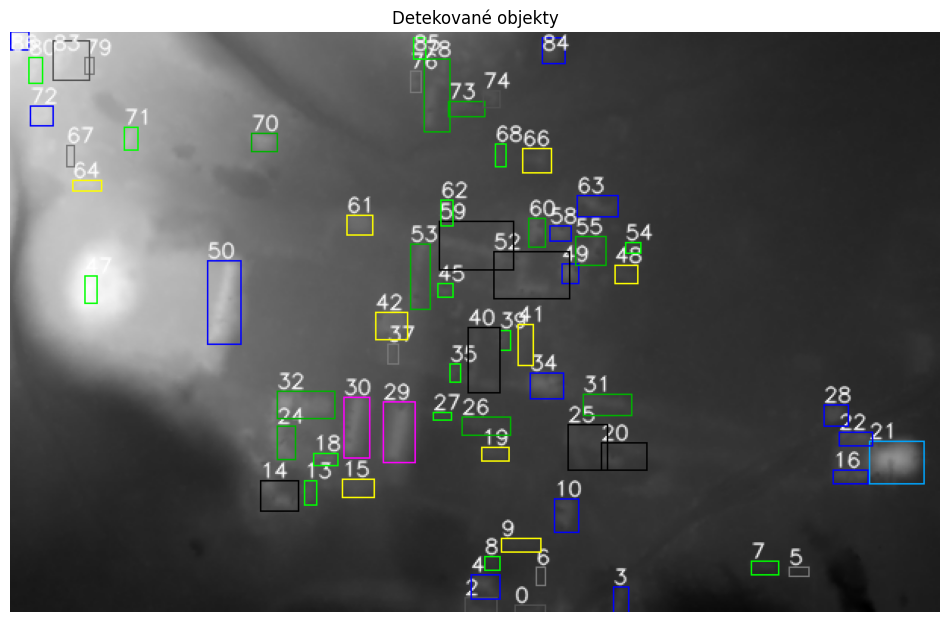

In [11]:
preview = cv2.normalize(dem, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
preview = cv2.cvtColor(preview, cv2.COLOR_GRAY2BGR)

def get_color(label):
    if label == "01_house":
        return (0, 255, 0)              # zelená

    elif label == "02_double_house":
        return (0, 180, 0)              # tmavšia zelená

    elif label in ["ruin_small", "ruin_elongated", "ruin_large_rectangular"]:
        return (120, 120, 120)          # sivá pre ruiny

    elif label in ["03_palace", "04_palace", "04_palace_large"]:
        return (255, 0, 0)              # modrá

    elif label == "11_temple_pyramida":
        return (255, 165, 0)            # oranžová

    elif label == "12_juego":
        return (255, 0, 255)            # fialová

    elif label == "cluster_houses":
        return (0, 0, 0)                # čierna

    elif label in ["15_platform_small", "16_platform_large"]:
        return (0, 255, 255)            # žltá

    elif label in [
        "unknown_small_building",
        "unknown_large_building",
        "unknown_elongated_building"
    ]:
        return (80, 80, 80)             # tmavšia sivá

    elif label in [
        "unknown_small_low",
        "unknown_large_low",
        "unknown_elongated_low"
    ]:
        return (160, 160, 160)          # svetlejšia sivá

    else:
        return (255, 255, 255)          # biela fallback


for idx, hinfo in enumerate(houses):
    orig_idx = hinfo[7]
    x, y, w, h = house_cord[orig_idx]
    label = hinfo[2]
    color = get_color(label)

    cv2.rectangle(preview, (x, y), (x + w, y + h), color, thickness=1)

    # ID číslo pôvodného objektu
    cv2.putText(
        preview,
        str(orig_idx),
        (x, max(12, y - 2)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 255, 255),
        1,
        cv2.LINE_AA
    )

plt.figure(figsize=(12, 12))
plt.imshow(preview[..., ::-1])
plt.title("Detekované objekty")
plt.axis("off")
plt.show()

In [17]:
ids_to_check = [48]

for hinfo in houses:
    if hinfo[7] in ids_to_check:
        print(f"ID {hinfo[7]} → trieda: {hinfo[2]}")

ID 48 → trieda: 16_platform_large


In [13]:
target_ids = [55]   # sem si daj ID objektov, ktoré chceš skontrolovať

for idx in target_ids:
    if idx < 0 or idx >= len(house_cord):
        print(f"\n===== DEBUG OBJECT {idx} =====")
        print("Objekt s týmto ID neexistuje.")
        print("================================\n")
        continue

    # --- základ ---
    x, y, w, h = house_cord[idx]
    short_side = min(w, h)
    long_side = max(w, h)
    aspect_ratio = long_side / short_side if short_side > 0 else 999
    diff = float(difference[idx]) if idx < len(difference) else 0.0

    mask = house[idx].astype(np.uint8)

    # --- plocha ---
    obj_area = float(np.sum(mask != 0))
    bbox_area = float(mask.shape[0] * mask.shape[1]) if mask.size > 0 else 1.0
    extent = obj_area / bbox_area if bbox_area > 0 else 0.0

    # --- kontúry ---
    mask255 = (mask > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    solidity = 0.0
    rectangularity = 0.0
    circularity = 0.0
    approx_vertices = 0

    if len(contours) > 0:
        cnt = max(contours, key=cv2.contourArea)
        cnt_area = cv2.contourArea(cnt)

        # convex hull
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = cnt_area / hull_area if hull_area > 0 else 0.0

        # perimeter + circularity
        perimeter = cv2.arcLength(cnt, True)
        if perimeter > 0:
            circularity = (4 * np.pi * cnt_area) / (perimeter * perimeter)

        # rectangularity
        rect = cv2.minAreaRect(cnt)
        rw, rh = rect[1]
        rect_area = rw * rh
        rectangularity = cnt_area / rect_area if rect_area > 0 else 0.0

        # approx vertices
        epsilon = 0.02 * perimeter if perimeter > 0 else 1.0
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        approx_vertices = len(approx)

    # --- výška ---
    avg_h = 0.0
    height_std = 0.0
    center_minus_edge = 0.0

    try:
        obj_heights = house_height[idx][mask != 0]
        if obj_heights.size > 0:
            avg_h = float(np.mean(obj_heights))
            height_std = float(np.std(obj_heights))

            # edge height
            edges = cv2.Canny((mask > 0).astype(np.uint8) * 255, 50, 150)
            edge_vals = house_height[idx][edges == 255]

            if edge_vals.size > 0:
                edge_h = np.mean(edge_vals)
                center_minus_edge = float(avg_h - edge_h)
    except Exception:
        pass

    # --- výpis ---
    print(f"\n===== DEBUG OBJECT {idx} =====")
    print(f"x={x}, y={y}, w={w}, h={h}")
    print(f"short={short_side}, long={long_side}, aspect_ratio={aspect_ratio:.2f}")
    print(f"area={obj_area:.1f}, bbox_area={bbox_area:.1f}, extent={extent:.2f}")
    print(f"solidity={solidity:.2f}, rectangularity={rectangularity:.2f}")
    print(f"circularity={circularity:.2f}, vertices={approx_vertices}")
    print(f"diff={diff:.2f}")
    print(f"avg_h={avg_h:.2f}, height_std={height_std:.2f}, center_minus_edge={center_minus_edge:.2f}")
    print("================================\n")


===== DEBUG OBJECT 55 =====
x=373, y=135, w=20, h=19
short=19, long=20, aspect_ratio=1.05
area=216.0, bbox_area=380.0, extent=0.57
solidity=0.80, rectangularity=0.64
circularity=0.53, vertices=8
diff=0.94
avg_h=147.35, height_std=0.79, center_minus_edge=0.49



### Finálny výstup detektora
V tomto kroku zobrazujeme finálny výstup klasifikačného algoritmu. Používame obraz `img_result`, ktorý obsahuje výsledky detekcie a klasifikácie zakreslené priamo do vstupného obrazu.

Výsledok vizualizujeme pomocou knižnice Matplotlib, pričom zabezpečujeme správne zobrazenie farieb. Týmto získavame prehľad o finálnom rozložení detegovaných objektov.

Zároveň výsledný obraz ukladáme do súboru vizualizacie.

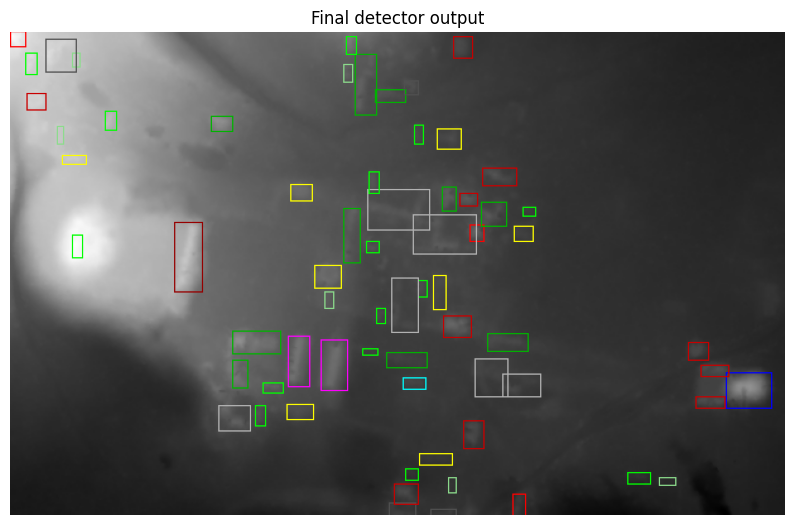

True

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(img_result[..., ::-1])
plt.title('Final detector output')
plt.axis('off')
plt.show()

cv2.imwrite('vizualizacie/final_detector_output.jpg', img_result)


### Výpočet rotovaného ohraničujúceho obdĺžnika
V tejto bunke definujeme funkciu `get_rotated_box`, ktorá slúži na výpočet vrcholov rotovaného obdĺžnika na základe stredu, rozmerov a uhla natočenia objektu.

Najprv prevádzame uhol zo stupňov na radiány a určujeme polovice strán obdĺžnika. Následne definujeme rohy obdĺžnika v lokálnom súradnicovom systéme vzhľadom na jeho stred.

Pomocou rotačnej matice vykonávame rotáciu týchto bodov o zadaný uhol. Po rotácii body posúvame do globálneho súradnicového systému podľa stredu objektu.

Výsledkom funkcie sú súradnice rotovaného obdĺžnika, ktoré môžeme využiť pri presnejšej vizualizácii v QGISe.

In [15]:
def get_rotated_box(cx, cy, w, h, angle_deg):
    angle = np.deg2rad(angle_deg)

    # polovice strán
    dx = w / 2
    dy = h / 2

    # rohy pred rotáciou (okolo stredu)
    corners = np.array([
        [-dx, -dy],
        [ dx, -dy],
        [ dx,  dy],
        [-dx,  dy]
    ])

    # rotačná matica
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    # rotácia + posun do stredu
    rotated = corners @ R.T
    rotated[:, 0] += cx
    rotated[:, 1] += cy

    return rotated

def clean_label(label):
    if label is None:
        return ""
    if "_" in label and label.split("_", 1)[0].isdigit():
        return label.split("_", 1)[1]
    return label

### Export výsledkov do WKT formátu
V tomto kroku realizujeme export výsledkov detekcie a klasifikácie objektov do formátu vhodného pre GIS nástroje. Najprv overujeme, či existujú detegované objekty.

Pre každý objekt získavame jeho stredové súradnice, rozmery a orientáciu. Pomocou funkcie `get_rotated_box` vypočítavame vrcholy rotovaného obdĺžnika, ktorý reprezentuje tvar objektu.

Následne uzatvárame polygon pridaním prvého bodu na koniec a vytvárame textovú reprezentáciu vo formáte WKT (Well-Known Text). Tento formát umožňuje jednoduchý import a vizualizáciu objektov v QGISe.

Výsledné údaje ukladáme do dátového rámca a exportujeme do CSV súboru. Ak nebol detegovaný žiadny objekt, súbor sa nevytvorí a vypíše sa veta, že súbor sa nepodarilo uložiť.


In [16]:
if len(houses) > 0:
    data = []
    data_centers = []

    for h in houses:
        idx = h[7]

        cx = h[0]
        cy = h[1]
        raw_label = h[2]
        label = clean_label(raw_label)
        angle = h[3]
        avg_height = h[4]
        w = h[5]
        h_box = h[6]

        box = get_rotated_box(cx, cy, w, h_box, angle)

        #uzavretenie polygonu (prvý bod na konci)
        coords = list(box) + [box[0]]

        wkt = "POLYGON((" + ", ".join([f"{pt[0]} {pt[1]}" for pt in coords]) + "))"

        data.append({
            'wkt': wkt,
            'label': h[2],
            'orientation': angle,
            'avg_height': h[4],
            'orig_index': idx
        })

    # stredy objektov
        data_centers.append({
            "center_x": cx,
            "center_y": cy,
            "label": label,
            "orientation": angle,
            "avg_height": avg_height,
            "orig_index": idx
        })

    df_wkt = pd.DataFrame(data)
    df_centers = pd.DataFrame(data_centers)

    out_wkt = "QGIS_csv/position_small_wkt.csv"
    out_centers = "QGIS_csv/position_small_centers.csv"

    df_wkt.to_csv(out_wkt, index=False)
    df_centers.to_csv(out_centers, index=False)

    print(f"Uložené do {out_wkt}")
    print(f"Uložené do {out_centers}")
    display(df_wkt.head())
    display(df_centers.head())
else:
    print("Neboli nájdené žiadne houses, súbor sa neuložil.")

Uložené do QGIS_csv/position_small_wkt.csv
Uložené do QGIS_csv/position_small_centers.csv


,wkt,label,orientation,avg_height,orig_index
0,"POLYGON((354.5 378.0, 354.5 382.0, 335.5 382.0...",unknown_elongated_building,90.000000,145.091293,0
1,"POLYGON((316.0 373.5, 316.0 382.5, 296.0 382.5...",unknown_elongated_building,90.000000,145.372086,2
2,"POLYGON((399.961538620021 364.6923076371084, 4...",03_palace,11.309933,144.766602,3
3,"POLYGON((303.73076984442906 356.3461539650255,...",04_palace,11.309933,145.756317,4
4,"POLYGON((525.0 352.5, 525.0 357.5, 513.0 357.5...",ruin_small,90.000000,143.415298,5


,center_x,center_y,label,orientation,avg_height,orig_index
0,345,380,unknown_elongated_building,90.000000,145.091293,0
1,306,378,unknown_elongated_building,90.000000,145.372086,2
2,402,374,palace,11.309933,144.766602,3
3,312,365,palace,11.309933,145.756317,4
4,519,355,ruin_small,90.000000,143.415298,5
